# Companion Notebook — *Mapping the Nodes of Universal Nouns Through Recursive Computational Verbs*

This notebook is a **companion** to the paper, not a replacement for it.

## Notebook goals
1. Build a compact **operator map** that can be explored directly in code.
2. Verify the paper's **SHA-256 bridge / coupling** claims that are executable from the standard algorithm.
3. Visualize the paper's key structural ideas with a small number of **teaching-oriented figures**.
4. Keep the workflow portable: **no hard-coded directories**, no automatic file dump, and optional exports only.

## Recommended use
- Read the paper first.
- Use this notebook to **interrogate the claims**, not to restate the manuscript.
- Change one thing at a time and watch what moves.


In [1]:
# Run once if your environment does not already have the required packages.
%pip install -q numpy pandas plotly


Note: you may need to restart the kernel to use updated packages.


## 0. Imports and notebook configuration

This cell keeps the notebook portable.

- `EXPORT_ARTIFACTS = False` means nothing is written unless you explicitly turn it on.
- `EXPORT_DIR` is relative to the notebook location, so the notebook can be moved without breaking paths.
- Random experiments use a fixed seed for repeatability.


In [2]:
from pathlib import Path
import math
import os
import random
import hashlib
import json

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

EXPORT_ARTIFACTS = False
EXPORT_DIR = Path("companion_outputs")
RNG_SEED = 1337
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

if EXPORT_ARTIFACTS:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def maybe_save_df(df: pd.DataFrame, name: str):
    if EXPORT_ARTIFACTS:
        df.to_csv(EXPORT_DIR / name, index=False)

def maybe_save_fig(fig, name: str):
    if EXPORT_ARTIFACTS:
        fig.write_html(str(EXPORT_DIR / name), include_plotlyjs="cdn")


## 1. The operator map

The paper proposes a compact operational grammar linking verbs to rendered nouns across substrates.  
This notebook uses a **minimal machine-readable version** of that map so the relationships can be inspected and plotted.

### What to look for
- The map is structured as a transition grammar, not a taxonomy of things.
- Several entries point directly into the SHA-256 round engine, which makes them executable here.


In [3]:
component_rows = [
    {"Variable": "S", "Verb": "Bearing",    "Universal role": "State-bearing substrate",                "SHA-256 companion view": "8 working registers a..h"},
    {"Variable": "B", "Verb": "Biasing",    "Universal role": "Directed potential / external drive",    "SHA-256 companion view": "K[i] and W[i] inputs"},
    {"Variable": "G", "Verb": "Ruling",     "Universal role": "Admissibility / threshold condition",    "SHA-256 companion view": "Boolean gate conditions"},
    {"Variable": "R", "Verb": "Routing",    "Universal role": "Transport path for change",              "SHA-256 companion view": "T1 message-side path"},
    {"Variable": "C", "Verb": "Conserving", "Universal role": "Continuity bridge",                      "SHA-256 companion view": "Carry / shared T1 coupling"},
    {"Variable": "K", "Verb": "Retaining",  "Universal role": "Persistence of generated state",         "SHA-256 companion view": "Register shift / state retention"},
    {"Variable": "X", "Verb": "Addressing", "Universal role": "Selection coordinate",                   "SHA-256 companion view": "Round index i"},
    {"Variable": "P", "Verb": "Projecting", "Universal role": "Rendered observable output",             "SHA-256 companion view": "a_new and e_new outputs"},
    {"Variable": "V", "Verb": "Closing",    "Universal role": "Verification / lawful-fit closure test", "SHA-256 companion view": "Differential invariant"},
]
component_df = pd.DataFrame(component_rows)
component_df


,Variable,Verb,Universal role,SHA-256 companion view
0,S,Bearing,State-bearing substrate,8 working registers a..h
1,B,Biasing,Directed potential / external drive,K[i] and W[i] inputs
2,G,Ruling,Admissibility / threshold condition,Boolean gate conditions
3,R,Routing,Transport path for change,T1 message-side path
4,C,Conserving,Continuity bridge,Carry / shared T1 coupling
5,K,Retaining,Persistence of generated state,Register shift / state retention
6,X,Addressing,Selection coordinate,Round index i
7,P,Projecting,Rendered observable output,a_new and e_new outputs
8,V,Closing,Verification / lawful-fit closure test,Differential invariant


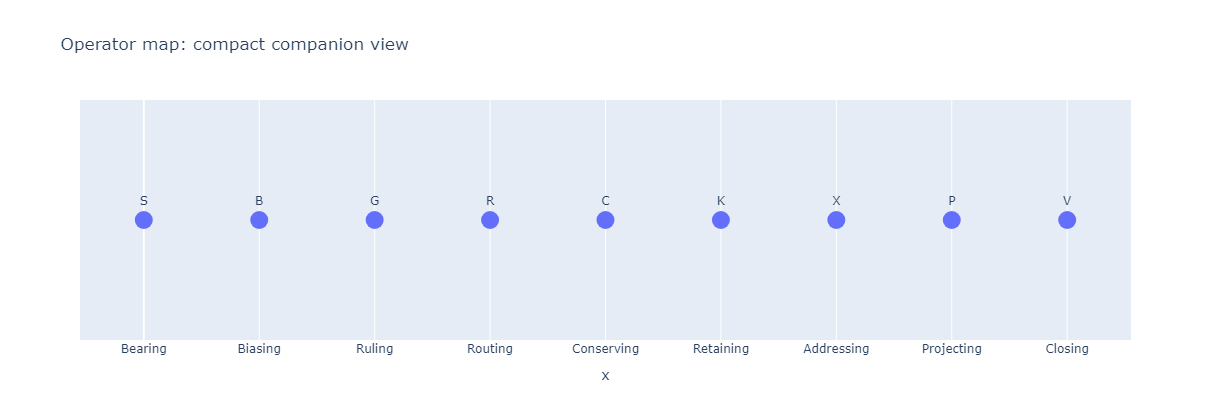

In [4]:
fig_operator_map = px.scatter(
    component_df.assign(x=np.arange(len(component_df)), y=np.ones(len(component_df))),
    x="x", y="y", text="Variable", hover_data=["Verb", "Universal role", "SHA-256 companion view"],
    title="Operator map: compact companion view"
)
fig_operator_map.update_traces(textposition="top center", marker=dict(size=18))
fig_operator_map.update_yaxes(visible=False, showticklabels=False)
fig_operator_map.update_xaxes(
    tickmode="array",
    tickvals=list(range(len(component_df))),
    ticktext=component_df["Verb"]
)
fig_operator_map.update_layout(height=420)
fig_operator_map.show()

maybe_save_df(component_df, "operator_map.csv")
maybe_save_fig(fig_operator_map, "fig_operator_map.html")


## 2. SHA-256 round engine as a teaching object

The paper frames the round engine as a bridge-separated architecture:
- a **North Bridge** driven by \(T2\),
- a **South Bridge** driven by \(T1\),
- and a **coupling identity** linking the outputs.

This section implements the standard SHA-256 one-block engine so those claims can be tested directly.


In [5]:
MASK32 = 0xFFFFFFFF

def rotr(x, n):
    return ((x >> n) | ((x << (32 - n)) & MASK32)) & MASK32

def ch(x, y, z):
    return (x & y) ^ (~x & z) & MASK32

def maj(x, y, z):
    return (x & y) ^ (x & z) ^ (y & z)

def Sigma0(x):
    return rotr(x, 2) ^ rotr(x, 13) ^ rotr(x, 22)

def Sigma1(x):
    return rotr(x, 6) ^ rotr(x, 11) ^ rotr(x, 25)

def sigma0(x):
    return rotr(x, 7) ^ rotr(x, 18) ^ (x >> 3)

def sigma1(x):
    return rotr(x, 17) ^ rotr(x, 19) ^ (x >> 10)

PRIMES = []
candidate = 2
while len(PRIMES) < 64:
    is_prime = True
    for p in range(2, int(candidate**0.5) + 1):
        if candidate % p == 0:
            is_prime = False
            break
    if is_prime:
        PRIMES.append(candidate)
    candidate += 1

H0 = [int((math.modf(math.sqrt(p))[0]) * 2**32) & MASK32 for p in PRIMES[:8]]
K = [int((math.modf(p ** (1/3))[0]) * 2**32) & MASK32 for p in PRIMES[:64]]

def pad_one_block(msg: bytes):
    ml = len(msg) * 8
    padded = msg + b"\x80"
    while len(padded) % 64 != 56:
        padded += b"\x00"
    padded += ml.to_bytes(8, "big")
    if len(padded) != 64:
        raise ValueError("This helper expects a single-block message (<=55 bytes).")
    return padded

def message_schedule(block: bytes):
    W = [int.from_bytes(block[i:i+4], "big") for i in range(0, 64, 4)]
    for i in range(16, 64):
        W.append((sigma1(W[i-2]) + W[i-7] + sigma0(W[i-15]) + W[i-16]) & MASK32)
    return W

def carry_out(total, word_bits=32):
    return total >> word_bits

def compress_trace(W, initial_state=None):
    if initial_state is None:
        initial_state = list(H0)

    a, b, c, d, e, f, g, h = initial_state
    rows = []

    for i in range(64):
        t1_terms = [h, Sigma1(e), ch(e, f, g), K[i], W[i]]
        t2_terms = [Sigma0(a), maj(a, b, c)]

        t1_sum = sum(t1_terms)
        t2_sum = sum(t2_terms)

        T1 = t1_sum & MASK32
        T2 = t2_sum & MASK32

        a_new = (T1 + T2) & MASK32
        e_new = (d + T1) & MASK32

        rows.append({
            "round": i,
            "a": a, "b": b, "c": c, "d": d, "e": e, "f": f, "g": g, "h": h,
            "W": W[i], "K": K[i],
            "T1": T1, "T2": T2,
            "carry_T1": carry_out(t1_sum),
            "carry_T2": carry_out(t2_sum),
            "a_new": a_new,
            "e_new": e_new,
            "sziklai_residual": ((a_new - e_new - (T2 - d)) & MASK32)
        })

        a, b, c, d, e, f, g, h = a_new, a, b, c, e_new, e, f, g

    return pd.DataFrame(rows)

abc_block = pad_one_block(b"abc")
W_abc = message_schedule(abc_block)
trace_abc = compress_trace(W_abc)
trace_abc.head()


,round,a,b,c,d,e,f,g,h,W,K,T1,T2,carry_T1,carry_T2,a_new,e_new,sziklai_residual
0,0,1779033703,3144134277,1013904242,2773480762,1359893119,2600822924,528734635,1541459225,1633837952,1116352408,1423593704,143694565,1,1,1567288269,4197074466,0
1,1,1567288269,1779033703,3144134277,1013904242,4197074466,1359893119,2600822924,528734635,0,1899447441,1012893207,504058774,1,1,1516951981,2026797449,0
2,2,1516951981,1567288269,1779033703,3144134277,2026797449,4197074466,1359893119,2600822924,0,3049323471,1036094310,2332146753,2,0,3368241063,4180228587,0
3,3,3368241063,1516951981,1567288269,1779033703,4180228587,2026797449,4197074466,1359893119,0,3921009573,3134595561,444257405,1,1,3578852966,618661968,0
4,4,3578852966,3368241063,1516951981,1567288269,618661968,4180228587,2026797449,4197074466,0,961987163,3863131768,503178226,1,1,71342698,1135452741,0


### 2.1 Ground check: the universal \(T2_0\)

A directly testable claim in the SHA discussion is that the initial north-bridge quantity

\[
T2_0 = \Sigma_0(a_0) + \operatorname{Maj}(a_0,b_0,c_0)
\]

is input-invariant because it is defined entirely by the initial state.


In [6]:
T2_0 = int(trace_abc.loc[0, "T2"])
hex(T2_0)


'0x8909ae5'

### 2.2 The coupling identity

The paper's coupling relation can be checked without interpretation.  
For each round:

\[
a_{i+1} - e_{i+1} \equiv T2_i - d_i \pmod{2^{32}}
\]

If the residual is always zero, the identity holds for the implemented round function.


In [7]:
int(trace_abc["sziklai_residual"].eq(0).all()), trace_abc["sziklai_residual"].sum()


(1, np.int64(0))

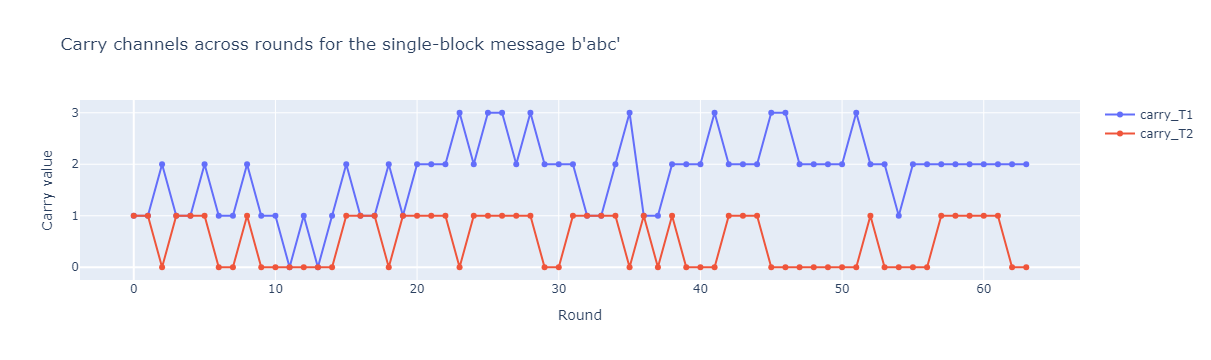

In [8]:
fig_round_channels = go.Figure()
fig_round_channels.add_trace(go.Scatter(
    x=trace_abc["round"], y=trace_abc["carry_T1"], mode="lines+markers", name="carry_T1"
))
fig_round_channels.add_trace(go.Scatter(
    x=trace_abc["round"], y=trace_abc["carry_T2"], mode="lines+markers", name="carry_T2"
))
fig_round_channels.update_layout(
    title="Carry channels across rounds for the single-block message b'abc'",
    xaxis_title="Round",
    yaxis_title="Carry value"
)
fig_round_channels.show()
maybe_save_fig(fig_round_channels, "fig_round_channels_abc.html")


## 3. Bridge-separated view

This diagram is intentionally minimal.  
It is a **teaching picture**, not a hardware schematic.

### What to look for
- \(T2\) depends only on \(a,b,c\).
- \(T1\) depends on \(e,f,g,h\) plus \(K[i]\) and \(W[i]\).
- The round emits two active injections: \(a_{new}\) and \(e_{new}\).


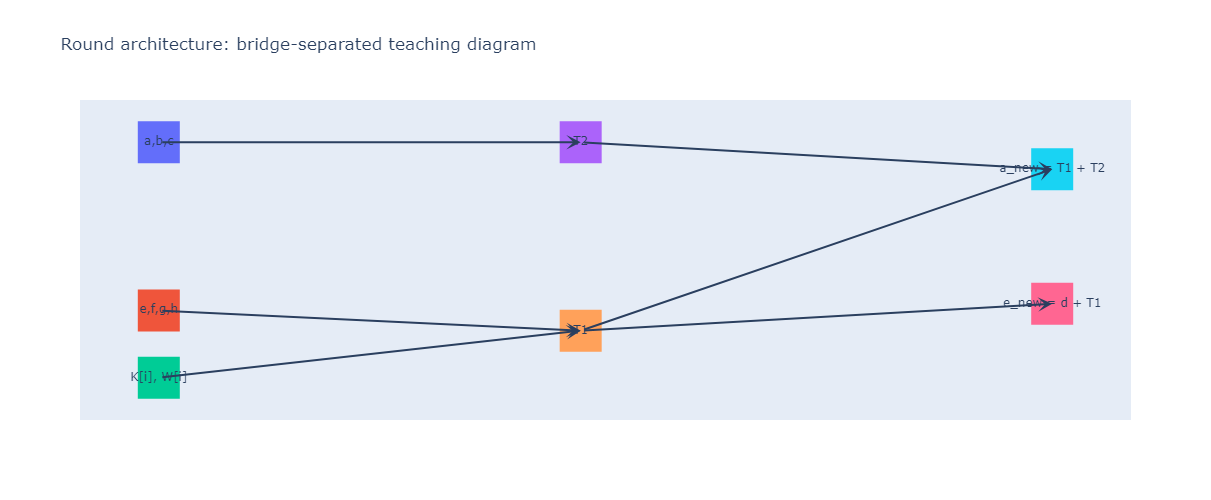

In [9]:
bridge_nodes = {
    "a,b,c": (0.08, 0.78),
    "e,f,g,h": (0.08, 0.28),
    "K[i], W[i]": (0.08, 0.08),
    "T2": (0.42, 0.78),
    "T1": (0.42, 0.22),
    "a_new = T1 + T2": (0.80, 0.70),
    "e_new = d + T1": (0.80, 0.30),
}
bridge_edges = [
    ("a,b,c", "T2"),
    ("e,f,g,h", "T1"),
    ("K[i], W[i]", "T1"),
    ("T2", "a_new = T1 + T2"),
    ("T1", "a_new = T1 + T2"),
    ("T1", "e_new = d + T1"),
]
fig_bridge = go.Figure()
for src, dst in bridge_edges:
    x0, y0 = bridge_nodes[src]
    x1, y1 = bridge_nodes[dst]
    fig_bridge.add_annotation(
        x=x1, y=y1, ax=x0, ay=y0,
        xref="x", yref="y", axref="x", ayref="y",
        showarrow=True, arrowhead=3, arrowsize=1.2, arrowwidth=2
    )
for label, (x, y) in bridge_nodes.items():
    fig_bridge.add_trace(go.Scatter(
        x=[x], y=[y], mode="markers+text", text=[label], textposition="middle center",
        marker=dict(size=42, symbol="square")
    ))
fig_bridge.update_layout(
    title="Round architecture: bridge-separated teaching diagram",
    showlegend=False, xaxis=dict(visible=False), yaxis=dict(visible=False),
    height=500
)
fig_bridge.show()
maybe_save_fig(fig_bridge, "fig_bridge_diagram.html")


## 4. Perturbation experiment

A good companion notebook should let you see **what changes first** when a message enters the engine.

Here we compare:
- a NOP-style schedule with all \(W[i]=0\),
- versus the real message schedule for `b"abc"`.

The plot shows how many bits differ lane-by-lane at each round.


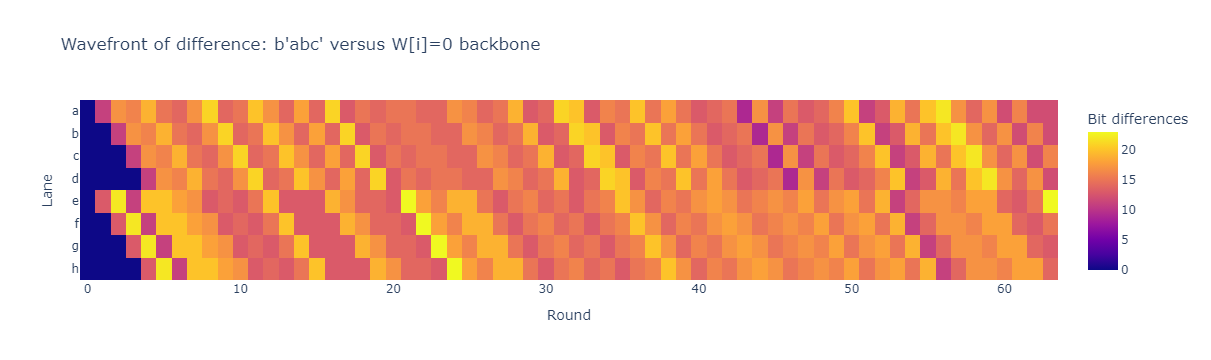

In [10]:
trace_nop = compress_trace([0] * 64)

lanes = list("abcdefgh")
delta_rows = []
for r in range(64):
    for lane in lanes:
        x = int(trace_abc.loc[r, lane])
        y = int(trace_nop.loc[r, lane])
        delta_rows.append({
            "round": r,
            "lane": lane,
            "hamming_delta": (x ^ y).bit_count()
        })
delta_df = pd.DataFrame(delta_rows)
delta_pivot = delta_df.pivot(index="lane", columns="round", values="hamming_delta")

fig_delta = px.imshow(
    delta_pivot,
    aspect="auto",
    labels=dict(x="Round", y="Lane", color="Bit differences"),
    title="Wavefront of difference: b'abc' versus W[i]=0 backbone"
)
fig_delta.show()

maybe_save_df(delta_df, "delta_wavefront.csv")
maybe_save_fig(fig_delta, "fig_delta_wavefront.html")


## 5. Carry entropy as a teaching measurement

The paper emphasizes the carry channel.  
This cell measures how variable the carry values are across random single-block messages.

### Interpretation
- Low entropy: the carry channel is locally predictable.
- High entropy: the carry channel is carrying more structural variation.
- This is a **measurement notebook** view, not a proof of any larger thesis by itself.


In [11]:
def random_one_block_message():
    n = random.randint(1, 55)
    return os.urandom(n)

def shannon_entropy(values):
    counts = pd.Series(values).value_counts(normalize=True)
    return float(-(counts * np.log2(counts)).sum())

sample_count = 96
carry_records = []
for _ in range(sample_count):
    msg = random_one_block_message()
    W = message_schedule(pad_one_block(msg))
    tr = compress_trace(W)
    for _, row in tr.iterrows():
        carry_records.append({
            "round": int(row["round"]),
            "carry_T1": int(row["carry_T1"]),
            "carry_T2": int(row["carry_T2"])
        })

carry_df = pd.DataFrame(carry_records)
entropy_by_round = carry_df.groupby("round").agg(
    entropy_carry_T1=("carry_T1", shannon_entropy),
    entropy_carry_T2=("carry_T2", shannon_entropy),
    mean_carry_T1=("carry_T1", "mean"),
    mean_carry_T2=("carry_T2", "mean"),
).reset_index()

entropy_by_round.head()


,round,entropy_carry_T1,entropy_carry_T2,mean_carry_T1,mean_carry_T2
0,0,0.295182,-0.000000,0.947917,1.000000
1,1,1.362593,0.928362,1.489583,0.656250
2,2,1.261101,0.988699,2.156250,0.437500
3,3,1.361266,0.994985,2.135417,0.458333
4,4,1.451663,0.979869,1.697917,0.583333


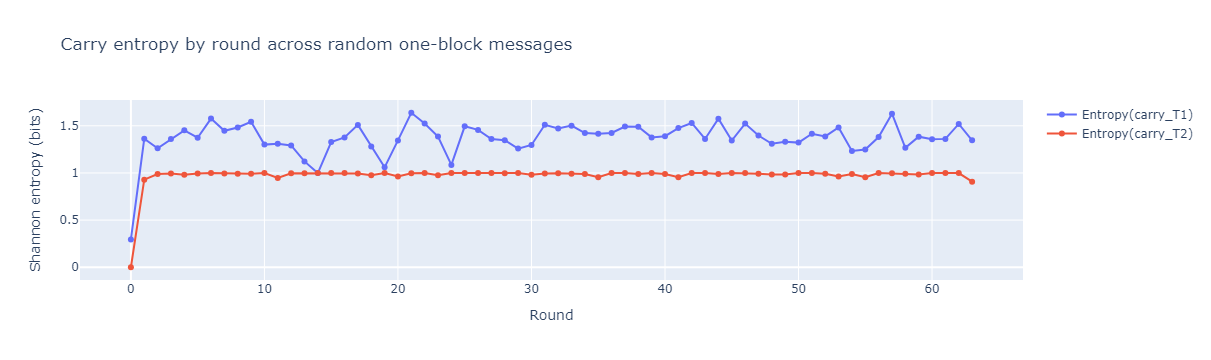

In [12]:
fig_entropy = go.Figure()
fig_entropy.add_trace(go.Scatter(
    x=entropy_by_round["round"], y=entropy_by_round["entropy_carry_T1"],
    mode="lines+markers", name="Entropy(carry_T1)"
))
fig_entropy.add_trace(go.Scatter(
    x=entropy_by_round["round"], y=entropy_by_round["entropy_carry_T2"],
    mode="lines+markers", name="Entropy(carry_T2)"
))
fig_entropy.update_layout(
    title="Carry entropy by round across random one-block messages",
    xaxis_title="Round",
    yaxis_title="Shannon entropy (bits)"
)
fig_entropy.show()

maybe_save_df(entropy_by_round, "carry_entropy_by_round.csv")
maybe_save_fig(fig_entropy, "fig_carry_entropy.html")


## 6. Mark 1 attractor as a compact numeric object

The notebook does not try to prove the broader interpretation.  
It does give the core number a clean numeric and geometric presentation.

\[
H = \frac{\pi}{9}
\]


In [13]:
H = math.pi / 9
mark1_df = pd.DataFrame([
    {"Quantity": "H", "Value": H},
    {"Quantity": "Degrees", "Value": math.degrees(H)},
    {"Quantity": "Complement 1-H", "Value": 1 - H},
    {"Quantity": "Distance from 0.35", "Value": abs(H - 0.35)},
])
mark1_df


,Quantity,Value
0,H,0.349066
1,Degrees,20.000000
2,Complement 1-H,0.650934
3,Distance from 0.35,0.000934


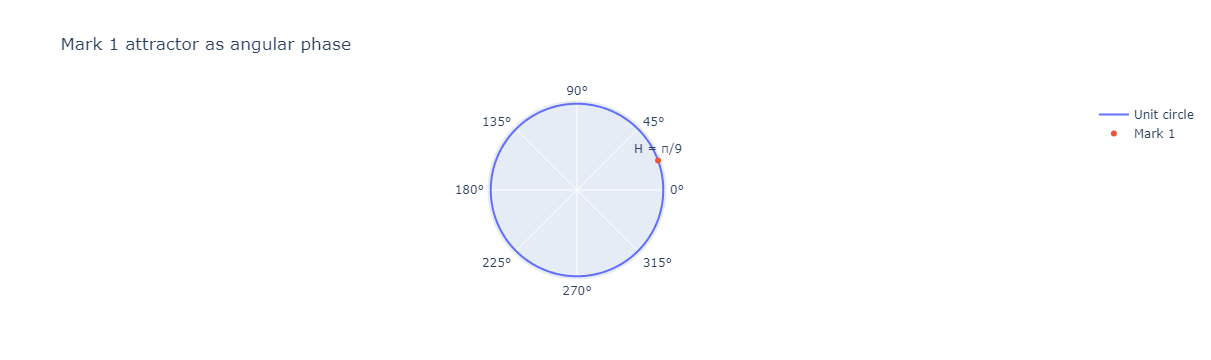

In [14]:
theta = np.linspace(0, 2 * np.pi, 600)
r = np.ones_like(theta)
fig_mark1 = go.Figure()
fig_mark1.add_trace(go.Scatterpolar(theta=np.degrees(theta), r=r, mode="lines", name="Unit circle"))
fig_mark1.add_trace(go.Scatterpolar(theta=[math.degrees(H)], r=[1], mode="markers+text", text=["H = π/9"], textposition="top center", name="Mark 1"))
fig_mark1.update_layout(
    title="Mark 1 attractor as angular phase",
    polar=dict(radialaxis=dict(visible=False))
)
fig_mark1.show()

maybe_save_fig(fig_mark1, "fig_mark1_phase.html")


## 7. Prime-root constants and BBP access

This final technical section keeps two ideas distinct:

1. **Prime-root constants** can be audited directly because they are part of SHA-256.
2. **BBP digit extraction** is a separate computational object and is best treated as its own experiment.

That separation keeps the notebook cleaner and prevents conceptual overreach.


In [15]:
prime_audit = pd.DataFrame({
    "index": np.arange(64),
    "prime": PRIMES,
    "K_hex": [f"0x{k:08x}" for k in K],
    "K_fractional": [k / 2**32 for k in K],
})
prime_audit.head(12)


,index,prime,K_hex,K_fractional
0,0,2,0x428a2f98,0.259921
1,1,3,0x71374491,0.442250
2,2,5,0xb5c0fbcf,0.709976
3,3,7,0xe9b5dba5,0.912931
4,4,11,0x3956c25b,0.223980
5,5,13,0x59f111f1,0.351335
6,6,17,0x923f82a4,0.571282
7,7,19,0xab1c5ed5,0.668402
8,8,23,0xd807aa98,0.843867
9,9,29,0x12835b01,0.072317


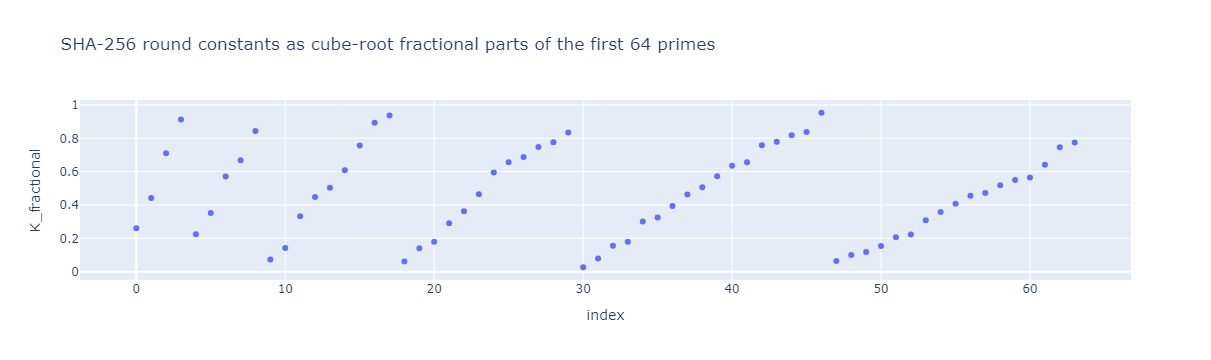

In [16]:
fig_prime = px.scatter(
    prime_audit,
    x="index",
    y="K_fractional",
    hover_data=["prime", "K_hex"],
    title="SHA-256 round constants as cube-root fractional parts of the first 64 primes"
)
fig_prime.show()
maybe_save_df(prime_audit, "prime_audit.csv")
maybe_save_fig(fig_prime, "fig_prime_constants.html")


### Optional: BBP word extraction

This cell is here as a separate teaching object.  
It is deliberately isolated from the SHA cells so the notebook does not imply a shortcut from BBP to SHA inversion.


In [17]:
# A compact BBP implementation for extracting hexadecimal digits of pi.
def bbp_pi_hex_digit(n: int) -> int:
    def S(j, n):
        total = 0.0
        for k in range(n + 1):
            total += pow(16, n - k, 8 * k + j) / (8 * k + j)
        k = n + 1
        term = 1.0
        while term > 1e-17:
            term = (16.0 ** (n - k)) / (8 * k + j)
            total += term
            k += 1
        return total

    x = (4 * S(1, n) - 2 * S(4, n) - S(5, n) - S(6, n)) % 1.0
    return int(16 * x)

def bbp_word(start_digit: int, digits: int = 8) -> str:
    out = []
    for i in range(digits):
        out.append(format(bbp_pi_hex_digit(start_digit + i), "x"))
    return "0x" + "".join(out)

bbp_df = pd.DataFrame([
    {"start_hex_digit": d, "word": bbp_word(d)}
    for d in [0, 8, 16, 32, 64, 128]
])
bbp_df


,start_hex_digit,word
0,0,0x243f6a88
1,8,0x85a308d3
2,16,0x13198a2e
3,32,0xa4093822
4,64,0x452821e6
5,128,0x9216d5d9


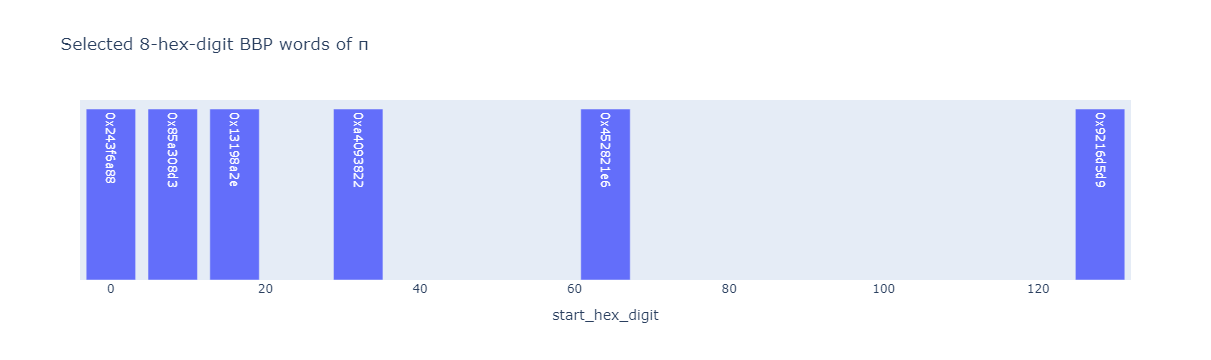

In [18]:
fig_bbp = px.bar(
    bbp_df,
    x="start_hex_digit",
    y=[1]*len(bbp_df),
    text="word",
    title="Selected 8-hex-digit BBP words of π",
    labels={"x": "Starting hexadecimal digit", "y": ""}
)
fig_bbp.update_yaxes(visible=False, showticklabels=False)
fig_bbp.show()
maybe_save_df(bbp_df, "bbp_words.csv")
maybe_save_fig(fig_bbp, "fig_bbp_words.html")


## 8. Exercises

1. Replace `b"abc"` with another short single-block message and rerun the perturbation heatmap.
2. Change the random sample count in the entropy section and watch how stable the entropy curves are.
3. Modify the bridge diagram labels to match your preferred terminology.
4. Turn `EXPORT_ARTIFACTS = True` only when you actually want files written.

The point of this notebook is not to archive the paper.  
The point is to make the paper's executable claims easier to test, teach, and extend.
